# Versioning ML Models — Tracking, Promoting, and Rolling Back

When you deploy a new model and it performs worse than the previous one, you need to roll back quickly. Model versioning is the practice of storing every trained model with its metadata so you can compare, promote, and revert reliably.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 5, lesson 01 "01. Grid Search and Random Search" — a sweep leaves you holding many trained candidates; versioning is what lets you tell them apart afterwards, promote one to production, and get back to the previous one when it disappoints.


## 📰 GitLab, 31 January 2017: the rollback that was not there

A GitLab engineer, working late on a replication problem, ran a directory-removal command against what turned out to be the **primary** production database rather than the secondary. Roughly 300 GB of live data vanished in seconds. That was the accident. The disaster was what came next: of the several backup and recovery mechanisms GitLab believed it had, essentially none worked when needed — the scheduled `pg_dump` had been failing silently for weeks because it ran a PostgreSQL 9.2 client against a 9.6 database, and the snapshot they eventually restored from took about **18 hours** to transfer. About **six hours of production data was permanently lost**: roughly 5,000 projects, 5,000 comments and 700 new user accounts. GitLab published the whole post-mortem in public, which is why we can teach from it.

**What goes wrong without this lesson.** "Roll back the model" is a sentence people say in incident calls as though it were an action. It is only an action if a previous version still exists, is loadable, is identified, and can be made live without a rebuild. Overwrite `model.pkl` on each training run and you have a system where the sentence is false — and you will find that out during the incident, not before it.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain why model versioning is necessary in production systems
2. Implement a file-based `ModelRegistry` class with register, promote, and rollback operations
3. Train multiple model versions, compare metrics, and promote the best one
4. Describe how MLflow extends this pattern for team-scale use

## 1. Why Versioning Matters

Without versioning:
- You overwrite `model.pkl` — the old model is gone forever
- You can't A/B test two models simultaneously
- Debugging a production regression requires re-training from scratch
- Compliance audits can't tell which model made which decision

With versioning: every model is stored with its training metadata. Promotion is a metadata update, rollback takes seconds.

## 2. File-Based Versioning Scheme

Before reaching for MLflow, understand the pattern it implements: each version lives in its own directory alongside a JSON metadata file.

In [1]:
# WHAT: wipe any registry left from earlier runs and preview the folder layout.
# WHY: the whole lesson builds this structure — one folder per version plus a
# production.json pointer, so 'which model is live' is data, not tribal knowledge.
import os, json, shutil
from pathlib import Path

# Clean up any previous runs
registry_root = Path("/tmp/model_registry")
if registry_root.exists():
    shutil.rmtree(registry_root)

# Show what the directory structure will look like
# Read this tree first: every method we write below maps to one part of it.
print("Target directory structure:")
print("""
/tmp/model_registry/
    v1/
        model.joblib          <- serialized sklearn model
        metadata.json         <- hyperparams, metrics, timestamp
    v2/
        model.joblib
        metadata.json
    production.json           <- pointer: which version is live
""")

Target directory structure:

/tmp/model_registry/
    v1/
        model.joblib          <- serialized sklearn model
        metadata.json         <- hyperparams, metrics, timestamp
    v2/
        model.joblib
        metadata.json
    production.json           <- pointer: which version is live



## 3. The ModelRegistry Class

This class wraps the directory layout into a clean API. In production systems like MLflow, this is exactly what the backend does — just with a database instead of JSON files.

In [2]:
# Define the ModelRegistry: one directory per version (model.joblib +
# metadata.json) plus a production.json pointer naming the live version.
# This is the same pattern MLflow implements with a database backend.
import joblib
import json
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional, Dict, Any

# The registry API: register / get_version / promote / get_production / list.
class ModelRegistry:
    """File-based model registry. Stores model artifacts + metadata per version."""

    def __init__(self, root: str = "/tmp/model_registry"):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self._prod_file = self.root / "production.json"

    # Write the artifact AND its metadata in one step — they must never separate.
    def register(self, model: Any, metrics: Dict[str, float],
                 hyperparams: Dict[str, Any], version: str) -> Path:
        """Save a model artifact and metadata under a named version."""
        version_dir = self.root / version
        version_dir.mkdir(exist_ok=True)

        # Save model artifact
        model_path = version_dir / "model.joblib"
        joblib.dump(model, model_path)

        # Save metadata alongside the artifact
        metadata = {
            "version": version,
            "registered_at": datetime.now(timezone.utc).isoformat(),
            "metrics": metrics,
            "hyperparams": hyperparams,
            "model_type": type(model).__name__
        }
        (version_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))
        print(f"Registered {version}: accuracy={metrics.get('accuracy', 'N/A'):.4f}")
        return model_path

    # Load any historical version by name — the basis for rollback.
    def get_version(self, version: str):
        """Load the model artifact for a specific version."""
        model_path = self.root / version / "model.joblib"
        if not model_path.exists():
            raise FileNotFoundError(f"Version '{version}' not found in registry")
        return joblib.load(model_path)

    def get_metadata(self, version: str) -> Dict:
        meta_path = self.root / version / "metadata.json"
        return json.loads(meta_path.read_text())

    # Promotion only rewrites the pointer file — the artifacts never move.
    def promote_to_production(self, version: str):
        """Mark a version as the production model. This is a metadata-only operation."""
        if not (self.root / version).exists():
            raise ValueError(f"Cannot promote: version '{version}' not registered")
        self._prod_file.write_text(json.dumps({"production_version": version,
                                               "promoted_at": datetime.now(timezone.utc).isoformat()}))
        print(f"Promoted {version} to PRODUCTION")

    # Serving code calls this: 'give me whatever is live right now'.
    def get_production(self):
        """Load whichever version is currently in production."""
        if not self._prod_file.exists():
            raise RuntimeError("No production model set yet")
        info = json.loads(self._prod_file.read_text())
        return self.get_version(info["production_version"]), info["production_version"]

    # Read every version's metadata — powers the comparison table later.
    def list_versions(self):
        """List all registered versions with their key metrics."""
        versions = []
        for d in sorted(self.root.iterdir()):
            meta_path = d / "metadata.json"
            if d.is_dir() and meta_path.exists():
                meta = json.loads(meta_path.read_text())
                versions.append(meta)
        return versions

registry = ModelRegistry()
print("Registry initialized at:", registry.root)

Registry initialized at: /tmp/model_registry


## 4. Train Three Model Versions

Each version uses different hyperparameters. We register each with its accuracy metric so we can compare them later.

We use a synthetic dataset that is deliberately *harder* than Iris (20 features, label noise). On Iris all three configurations score a perfect 1.0000 — a three-way tie teaches nothing about picking a winner. Here the accuracies genuinely differ, so "compare and promote the best" is a real decision.

In [3]:
# Train and register three model versions with different hyperparameters.
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Harder-than-Iris synthetic data: 20 features, 6% label noise — accuracy now
# actually depends on model capacity, so the versions are distinguishable.
X, y = make_classification(
    n_samples=1200, n_features=20, n_informative=8, n_redundant=4,
    flip_y=0.06, random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Version configurations to compare: capacity grows from v1 to v3
versions_config = [
    {"version": "v1", "n_estimators": 10,  "max_depth": 3},
    {"version": "v2", "n_estimators": 50,  "max_depth": 5},
    {"version": "v3", "n_estimators": 200, "max_depth": None},  # no depth limit
]

# Train each configuration and register it with its held-out accuracy
for cfg in versions_config:
    version = cfg.pop("version")
    model = RandomForestClassifier(**cfg, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    registry.register(
        model=model,
        metrics={"accuracy": acc},
        hyperparams=cfg,
        version=version
    )


Registered v1: accuracy=0.7400
Registered v2: accuracy=0.7933


Registered v3: accuracy=0.8367


## 5. Compare Versions and Promote the Best One

In [4]:
# WHAT: list every registered version with its metrics and pick the best by accuracy.
# WHY: model selection should read the registry's recorded metadata — not retrain
# or re-evaluate — so promotion decisions are reproducible and auditable.
# List all versions with metrics
print(f"{'Version':<10} {'Accuracy':<12} {'n_estimators':<15} {'max_depth'}")
print("-" * 50)

best_version = None
best_accuracy = 0.0

# Track the running best while printing one comparison row per version.
for meta in registry.list_versions():
    acc = meta["metrics"]["accuracy"]
    hp  = meta["hyperparams"]
    print(f"{meta['version']:<10} {acc:<12.4f} {hp.get('n_estimators','?'):<15} {hp.get('max_depth','None')}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_version = meta["version"]

print(f"\nBest version: {best_version} (accuracy={best_accuracy:.4f})")

Version    Accuracy     n_estimators    max_depth
--------------------------------------------------
v1         0.7400       10              3
v2         0.7933       50              5
v3         0.8367       200             None

Best version: v3 (accuracy=0.8367)


In [5]:
# Promote the best version to production
registry.promote_to_production(best_version)

# Verify: load the production model and check predictions match
prod_model, prod_version = registry.get_production()
prod_acc = accuracy_score(y_test, prod_model.predict(X_test))
print(f"Production model: {prod_version}, accuracy={prod_acc:.4f}")

Promoted v3 to PRODUCTION
Production model: v3, accuracy=0.8367


## 6. Rollback — Promoting a Previous Version

If the live production version starts causing errors (bad data, incompatible dependency), you can roll back by calling `promote_to_production` on an earlier version. It's just a metadata pointer update — the model artifact is already stored.

The next cell reads which version is *actually* live from the registry and rolls back to the version registered just before it — nothing is hard-coded.

In [6]:
# Simulate a rollback: read the LIVE version from the registry, then re-promote
# the version registered just before it. No version names are hard-coded — the
# printed story always matches what the registry actually did above.

# Which version is serving right now?
_, live_version = registry.get_production()

# Pick the version registered immediately before the live one as the target
version_order = [meta["version"] for meta in registry.list_versions()]
live_idx = version_order.index(live_version)
target_version = version_order[live_idx - 1] if live_idx > 0 else version_order[0]

print(f"Live version: {live_version} — simulating a production incident...")
print(f"Rolling back from {live_version} to {target_version}...")
registry.promote_to_production(target_version)

# Confirm the pointer moved
prod_model, prod_version = registry.get_production()
print(f"Production is now: {prod_version}")
print("Rollback complete — serving predictions again in < 1 second")


Live version: v3 — simulating a production incident...
Rolling back from v3 to v2...
Promoted v2 to PRODUCTION
Production is now: v2
Rollback complete — serving predictions again in < 1 second


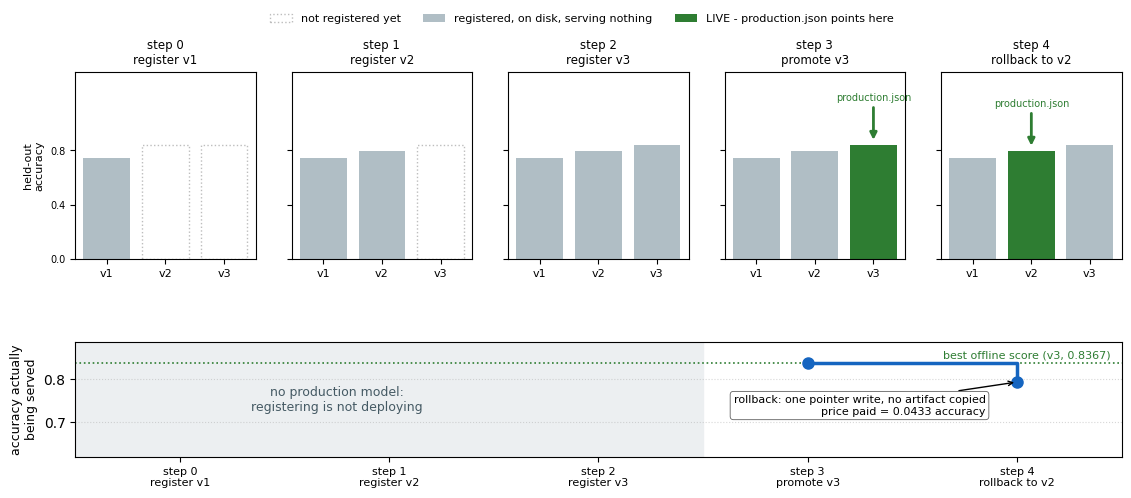

step   operation                      versions on disk     live         accuracy served
0      register v1                    v1                   (none yet)   -
1      register v2                    v1,v2                (none yet)   -
2      register v3                    v1,v2,v3             (none yet)   -
3      promote v3                     v1,v2,v3             v3           0.8367
4      rollback to v2                 v1,v2,v3             v2           0.7933

Rollback moved one JSON pointer from v3 to v2: 0.0433 accuracy given up, zero artifacts copied,
and every version still on disk and re-promotable at any time.


In [7]:
# WHAT: draw the registry as a storyboard - one frame per operation this notebook
# performed, each frame showing which versions exist and which one production points at -
# with a strip underneath tracking the accuracy actually being served at that moment.
# WHY: "promotion and rollback are metadata writes" is a claim about a POINTER MOVING
# through time. A single bar chart of accuracies cannot show movement; a row of frames
# that differ only in which bar is green can, and the strip prices each move.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Read every fact back out of the registry rather than retyping it.
metas = registry.list_versions()
names = [m["version"] for m in metas]
accs = [m["metrics"]["accuracy"] for m in metas]
idx_of = {v: i for i, v in enumerate(names)}

# The exact sequence of operations the cells above ran, with the state after each one.
# (label, versions that exist by now, version production points at or None)
storyboard = []
for i, v in enumerate(names):
    storyboard.append((f"register {v}", names[: i + 1], None))
storyboard.append((f"promote {best_version}", names, best_version))
storyboard.append((f"rollback to {target_version}", names, target_version))

served = [accs[idx_of[live]] if live else float("nan") for _lbl, _ex, live in storyboard]
n = len(storyboard)

fig = plt.figure(figsize=(13.5, 5.0))
gs = fig.add_gridspec(2, n, height_ratios=[2.2, 1.35], hspace=0.55)

# --- Row 1: one frame per step. Bar height = that version's recorded accuracy. ---
for i, (label, existing, live) in enumerate(storyboard):
    ax = fig.add_subplot(gs[0, i])
    for j, v in enumerate(names):
        if v not in existing:                      # not registered yet: nothing on disk
            ax.bar(j, max(accs), color="none", edgecolor="#bdbdbd", ls=":", lw=1.0)
        elif v == live:                            # production.json names this one
            ax.bar(j, accs[j], color="#2e7d32")
        else:                                      # registered, on disk, serving nothing
            ax.bar(j, accs[j], color="#b0bec5")
    if live is not None:                           # the pointer itself, drawn as an arrow
        ax.annotate("", xy=(idx_of[live], accs[idx_of[live]] + 0.02),
                    xytext=(idx_of[live], accs[idx_of[live]] + 0.30),
                    arrowprops=dict(arrowstyle="-|>", lw=2, color="#2e7d32"))
        ax.text(idx_of[live], accs[idx_of[live]] + 0.33, "production.json",
                ha="center", fontsize=7, color="#2e7d32")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=8)
    ax.set_ylim(0, max(accs) * 1.65)
    ax.set_yticks([0, 0.4, 0.8])
    ax.tick_params(axis="y", labelsize=7)
    if i == 0:
        ax.set_ylabel("held-out\naccuracy", fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.set_title(f"step {i}\n{label}", fontsize=8.5)

fig.legend(handles=[Patch(facecolor="none", edgecolor="#bdbdbd", ls=":", label="not registered yet"),
                    Patch(facecolor="#b0bec5", label="registered, on disk, serving nothing"),
                    Patch(facecolor="#2e7d32", label="LIVE - production.json points here")],
           loc="upper center", ncol=3, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.015))

# --- Row 2: what the pointer costs - the accuracy actually reaching users -------
ax = fig.add_subplot(gs[1, :])
first_live = next(i for i, s in enumerate(served) if s == s)          # first non-NaN step
ax.axvspan(-0.5, first_live - 0.5, color="#eceff1")
ax.text((first_live - 0.5) / 2 / n, 0.5,
        "no production model:\nregistering is not deploying",
        transform=ax.transAxes, ha="center", va="center",
        fontsize=9, color="#455a64")
ax.axhline(max(accs), ls=":", lw=1.2, color="#2e7d32")
ax.text(n - 0.55, max(accs) + 0.012, f"best offline score ({best_version}, {max(accs):.4f})",
        fontsize=8, color="#2e7d32", ha="right")
ax.step(range(n), served, where="post", color="#1565c0", lw=2.5)
ax.plot(range(n), served, "o", color="#1565c0", ms=8)
drop = accs[idx_of[best_version]] - accs[idx_of[target_version]]
ax.annotate(f"rollback: one pointer write, no artifact copied\n"
            f"price paid = {drop:.4f} accuracy",
            xy=(n - 1, served[-1]), xytext=(n - 1.15, served[-1] - 0.075),
            fontsize=8, ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#616161", lw=0.6),
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(min(accs) - 0.12, max(accs) + 0.05)
ax.set_xticks(range(n))
ax.set_xticklabels([f"step {i}\n{lbl}" for i, (lbl, _e, _l) in enumerate(storyboard)], fontsize=8)
ax.set_ylabel("accuracy actually\nbeing served", fontsize=9)
ax.grid(axis="y", ls=":", alpha=0.5)

plt.show()

# The same storyboard as a step table, so the figure is never the only record.
print(f"{'step':<6} {'operation':<30} {'versions on disk':<20} {'live':<12} accuracy served")
for i, (label, existing, live) in enumerate(storyboard):
    acc = f"{accs[idx_of[live]]:.4f}" if live else "-"
    print(f"{i:<6} {label:<30} {','.join(existing):<20} {live or '(none yet)':<12} {acc}")
print(f"\nRollback moved one JSON pointer from {best_version} to {target_version}: "
      f"{drop:.4f} accuracy given up, zero artifacts copied,\nand every version still on disk "
      f"and re-promotable at any time.")


**Reading the storyboard.** Five frames, one per operation the cells above actually performed.
Inside every frame the same three bars stand for `v1`, `v2` and `v3`, and each bar's height is
the accuracy that version recorded at register time — so the frames differ only in **what
exists** and **what is live**.

Watch the first three frames: bars appear one at a time as each version is registered, and
**not one of them turns green**. Registering a model puts an artifact on disk; it does not put
it in front of users. That is the entire reason a separate `production.json` exists, and it is
why the strip underneath is blank across that greyed region. At step 3 the promote call moves
the pointer to the best-scoring version and one bar turns green; at step 4 the incident moves
it back, and a *different, shorter* bar turns green.

The strip is the price tag. It plots the accuracy actually reaching users, against the dotted
line marking the best score any registered version ever achieved. The final step sits below
that line by the amount the annotation names: **that gap is what the rollback bought you.**
Nothing was copied, retrained or rebuilt between the last two frames — every one of the three
artifacts is still on disk in both — which is why the notebook could truthfully print "serving
predictions again in < 1 second". The tall grey bar in the last frame is the whole point: the
better model is still there, one pointer write away, for when you have fixed what broke.


## 💬 Discuss

The registry did what it promised: v3 scored **0.8367** against v1's 0.7400, was promoted, and the rollback to v2 completed in under a second because it is a pointer write rather than a file copy. Now argue the parts the printed numbers leave open.

1. Rollback took under a second — but v2 scores **0.7933**, meaningfully worse than v3. Rolling back is not free; you are choosing a known-worse model. What evidence would make you take that trade, and what would you need to see before rolling *forward* to a fix instead?
2. `promote_to_production` accepts any registered version. Should it? Write the preconditions you would enforce (Unit 1 notebook 05 built some of them), and say who is allowed to override each one at 2 a.m.
3. GitLab's backups existed on paper and failed in practice. Design the smallest possible test that proves your registry can actually roll back — one that runs on a schedule, not one that runs during an incident. What would it have to do?

## 7. MLflow — The Production-Standard Registry

Our file-based registry teaches the concept, but production teams use MLflow. It adds:
- A web UI for browsing experiments and comparing metrics visually
- Staging / Production / Archived lifecycle stages
- Git commit tracking so you can reproduce any training run
- Team access control

The code below shows the MLflow equivalent. If `mlflow` is installed, you can run it; otherwise read it to understand the mapping.

In [8]:
# MLflow equivalent — shows the same pattern with a richer backend
# Install: pip install mlflow
# Note: this cell is intentionally shown but requires mlflow installed to run

mlflow_example = '''
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:///tmp/mlruns")
mlflow.set_experiment("iris-classifier")

# Log a training run
with mlflow.start_run(run_name="rf-v3"):
    mlflow.log_params({"n_estimators": 200, "max_depth": None})
    mlflow.log_metric("accuracy", 0.9667)

    # Log the model artifact to the run
    mlflow.sklearn.log_model(clf, artifact_path="model")

# Register in the model registry (separate from the experiment run)
run_id = mlflow.last_active_run().info.run_id
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, name="iris-classifier")

# Promote to production via the MlflowClient
from mlflow.tracking import MlflowClient
client = MlflowClient()
client.transition_model_version_stage(
    name="iris-classifier", version=3, stage="Production"
)
'''

print("MLflow equivalent code (requires: pip install mlflow):")
print(mlflow_example)
print("Key mapping:")
print("  registry.register()         -> mlflow.sklearn.log_model() + register_model()")
print("  registry.promote_to_production() -> client.transition_model_version_stage(stage='Production')")
print("  registry.get_production()   -> mlflow.sklearn.load_model('models:/iris-classifier/Production')")

MLflow equivalent code (requires: pip install mlflow):

import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:///tmp/mlruns")
mlflow.set_experiment("iris-classifier")

# Log a training run
with mlflow.start_run(run_name="rf-v3"):
    mlflow.log_params({"n_estimators": 200, "max_depth": None})
    mlflow.log_metric("accuracy", 0.9667)

    # Log the model artifact to the run
    mlflow.sklearn.log_model(clf, artifact_path="model")

# Register in the model registry (separate from the experiment run)
run_id = mlflow.last_active_run().info.run_id
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, name="iris-classifier")

# Promote to production via the MlflowClient
from mlflow.tracking import MlflowClient
client = MlflowClient()
client.transition_model_version_stage(
    name="iris-classifier", version=3, stage="Production"
)

Key mapping:
  registry.register()         -> mlflow.sklearn.log_model() + register_model()
  registry.promote_to_production() -> clie

## 8. Summary

In this notebook you:
- Built a `ModelRegistry` class that stores models in versioned directories with JSON metadata
- Trained 3 model versions with different hyperparameters and compared their accuracy on held-out data
- Promoted the best version to production (a metadata pointer update, not a file copy)
- Demonstrated rollback: re-promoting the previously registered version after the best one was live — one `promote_to_production` call, under a second
- Mapped the file-based pattern to MLflow's `log_model` / `register_model` / `transition_model_version_stage`

**The registry pattern:** store artifact + metadata at register time; promotion and rollback are just metadata writes.


## Self-Check (answer before scrolling up)

1. **What information should you store alongside a model artifact?** List at least three fields from this notebook's `metadata.json`.
2. **What is the difference between 'staging' and 'production' in a model registry?** Why have two separate stages?
3. **How would you roll back from v3 to v1 if v3 performs worse in production?** Describe the exact operation using this notebook's `ModelRegistry` API.

## ⚠️ Where this breaks

- **A rollback that has never been rehearsed is a hypothesis.** GitLab's recovery paths all existed; the one that mattered had been broken for weeks and nobody knew, because nothing tested it. If `promote_to_production` is not exercised on a schedule against a real artifact, treat your rollback capability as unproven.
- **The pointer flips instantly; the *system* does not.** `production.json` changes in a millisecond. The serving processes that already loaded v3 into memory keep serving v3 until they reload or restart. Between those two moments you are running two model versions at once — which is fine if you planned it and confusing if you did not (Unit 4 notebook 02 shows what Kubernetes does about it).
- **Rolling back the model does not roll back its consequences.** Predictions already written to a database, emails already sent, prices already quoted, loans already declined — none of that reverses. Ask early which of your model's outputs are *reversible*, because that determines how much a fast rollback is actually worth.
- **The assumption that must hold:** every registered artifact is still loadable. A `model.joblib` from six months ago needs the library versions from six months ago. A registry without a pinned environment beside each version stores files you cannot open (Unit 5, notebook 06).
- **Accuracy is not a promotion criterion by itself.** Our comparison ranks three versions on one number from one split. Real promotion needs the same held-out set for every candidate, plus latency, plus per-segment performance — and even then, offline ranking has been shown to disagree with live outcomes (Unit 3, notebook 03). Section 5's "best version" is a shortlist, not a decision.
- **The cheaper alternative.** For one model retrained twice a year by one person, this directory-plus-JSON scheme is genuinely enough and MLflow is overhead. Reach for a real registry when several people train, several models exist, or an auditor will ask which version made a specific decision.

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Amershi, S., Begel, A., Bird, C., et al. (2019). *Software Engineering for Machine Learning: A Case Study*. ICSE-SEIP. <https://www.microsoft.com/en-us/research/publication/software-engineering-for-machine-learning-a-case-study/>
3. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2022). *Operationalizing Machine Learning: An Interview Study*. arXiv. <https://arxiv.org/abs/2209.09125>
4. Zampetti, F., Stocchetti, F., Razzano, F., Tamburri, D. A., & Di Penta, M. (2026). *How are MLOps Frameworks Used in Open Source Projects? An Empirical Characterization*. arXiv. <https://arxiv.org/abs/2601.18591> — analyses how dependent GitHub projects actually invoke the APIs and commands of eight popular open-source MLOps frameworks, and which features they never touch. Worth reading against section 7: teams adopt a framework and then use a subset of it, which is why understanding the underlying registry pattern still matters.
5. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv. <https://arxiv.org/abs/2606.09809> — argues that evaluation results are reported so inconsistently that readers cannot compare them across sources or trace a claim back to its evidence. That is exactly the weakness of promoting a version on one accuracy number from one split, which the "Where this breaks" section above already flags.
